## 1. 导包

In [25]:
from pathlib import Path
import random

import matplotlib.pyplot as plt
import numpy as np
import torch

from config import config
from env import GridWorld
from rollout import ReplayBuffer, uniform_rollout
from runner import DQN_Runner
from visualize import plot_policy, plot_training_curve

## 2. 参数配置与经验采集

In [26]:
cfg = config(
        # env config
        row_num=5,col_num=5,
        reward={
            "boundary":-10,
            "forbidden":-10,
            "target":10,
            "blank":0
        },
        # 0为空白，1为禁止，2为目标
        grid=[
            [0,0,0,0,0],
            [0,1,1,0,0],
            [0,0,1,0,0],
            [0,1,2,1,0],
            [0,1,0,0,0]
        ],

        # rl config
        epsilon=0.1,
        gamma=0.95,
        lr=5e-4,
        batch_size=256,
        target_update_interval=50,
        train_iteration=20000,
        device="cuda:0",
        # rollout config
        rollout_steps=10000,
        # random
        seed=123456,
        # net config
        input_dim=2,
        output_dim=5,
        hidden_dim=[100,50]
)

random.seed(cfg.rand.seed)
np.random.seed(cfg.rand.seed)
torch.manual_seed(cfg.rand.seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(cfg.rand.seed)

if cfg.rollout.steps < cfg.rl.batch_size:
    raise ValueError("rollout steps must be at least as large as batch_size")

env = GridWorld(cfg)
replay_buffer = ReplayBuffer(
    capacity=cfg.rollout.steps,
    seed=cfg.rand.seed,
)
rollout_return, rollout_rewards = uniform_rollout(
    env=env,
    cfg=cfg,
    replay_buffer=replay_buffer,
)

print(f"replay buffer size: {len(replay_buffer)}")
print(f"rollout return: {rollout_return:.2f}")

replay buffer size: 10000
rollout return: -35590.00


## 3. DQN 训练

In [27]:
runner = DQN_Runner(cfg)
losses = []
report_interval = max(1, cfg.rl.train_iteration // 10)

for iteration in range(1, cfg.rl.train_iteration + 1):
    loss = runner.train_step(replay_buffer)
    losses.append(loss)

    if iteration == 1 or iteration % report_interval == 0:
        print(f"iteration={iteration:4d}  loss={loss:.6f}")

print(f"device: {runner.device}")

iteration=   1  loss=45.626205
iteration=2000  loss=22.537136
iteration=4000  loss=26.368151
iteration=6000  loss=22.076422
iteration=8000  loss=15.253294
iteration=10000  loss=9.347163
iteration=12000  loss=1.927693
iteration=14000  loss=0.761212
iteration=16000  loss=0.244540
iteration=18000  loss=0.066354
iteration=20000  loss=0.024459
device: cuda:0


## 4. 训练结果可视化

greedy policy (0=up, 1=right, 2=down, 3=left, 4=stay):
[[2 1 2 2 2]
 [2 2 2 2 2]
 [1 1 2 3 3]
 [1 1 4 3 3]
 [1 1 0 3 3]]
figures saved to: D:\My Knowledge\AI algorithm&architecture\Reinforcement-Learning\code\DQN\output


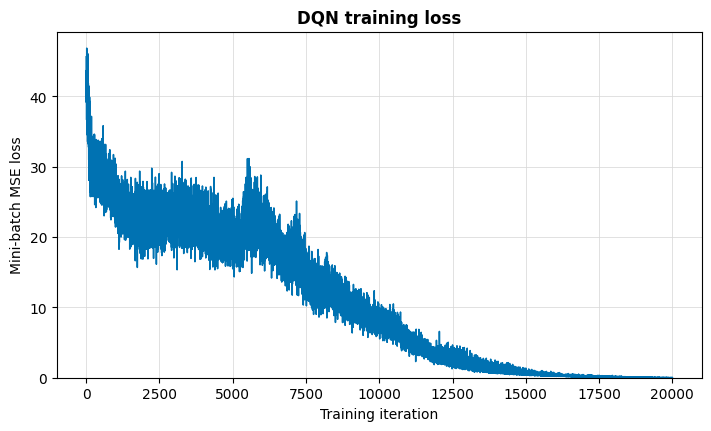

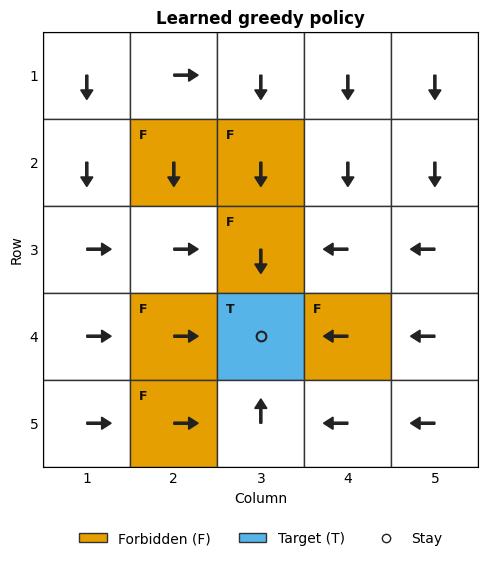

In [28]:
workspace = Path.cwd().parent if Path.cwd().name == 'code' else Path.cwd()
output_dir = workspace / 'output'
output_dir.mkdir(parents=True, exist_ok=True)

plot_training_curve(
    losses,
    save_path=output_dir / 'dqn_training_loss.png',
    show=False,
)
_, _, policy, q_values = plot_policy(
    runner,
    cfg,
    save_path=output_dir / 'dqn_greedy_policy.png',
    show=False,
)

print("greedy policy (0=up, 1=right, 2=down, 3=left, 4=stay):")
print(policy)
print(f"figures saved to: {output_dir.resolve()}")
plt.show()

## 5. 与最优 baseline 对比

使用 `evaluate.py` 的价值迭代，在训练时相同的 `cfg`（地图、奖励、折扣因子）下计算最优策略。
统计包含所有格子（含禁止格和目标格），与环境随机起点的范围一致；选择任一并列最优动作均算正确。

- **Optimal action fraction**：最优动作命中率，越接近 100% 越好。
- **Mean / max value gap**：最优价值与 DQN 贪心策略实际价值的差距，越接近 0 越好。
- DQN 策略价值通过环境模型求解，不是网络预测的最大 Q 值。浮点误差可能产生极小的负差值。

方向图中 `F` 为可进入但有惩罚的禁止格，`T` 为非终止目标格，圆圈表示停留；baseline 展示所有并列最优方向，DQN 图中的 `!` 标记非最优动作。

In [29]:
from evaluate import optimal_reference, evaluate_policy
from visualize import compute_greedy_policy

baseline = optimal_reference(cfg)
dqn_policy, dqn_q_values = compute_greedy_policy(runner, cfg)
comparison = evaluate_policy(dqn_policy, cfg, reference=baseline)
metrics = comparison["metrics"]

print(f"Optimal action fraction: {metrics['optimal_action_fraction']:.2%}")
print(f"Mean value gap:           {metrics['mean_value_gap']:.6f}")
print(f"Max value gap:            {metrics['max_value_gap']:.6f}")
print(f"Mean DQN policy value:   {metrics['mean_policy_value']:.6f}")
print(f"Mean optimal value:      {metrics['mean_optimal_value']:.6f}")
print(f"Baseline Bellman residual: {baseline['bellman_residual']:.3e}")
print("\nValue gap per starting cell (V* - V_DQN):")
print(np.array2string(comparison["value_gap"], precision=3, suppress_small=True))

Optimal action fraction: 96.00%
Mean value gap:           0.020000
Max value gap:            0.500000
Mean DQN policy value:   176.998200
Mean optimal value:      177.018200
Baseline Bellman residual: 9.948e-13

Value gap per starting cell (V* - V_DQN):
[[-0.  -0.  -0.  -0.  -0. ]
 [-0.  -0.  -0.  -0.  -0. ]
 [-0.  -0.  -0.  -0.  -0. ]
 [-0.  -0.  -0.  -0.  -0. ]
 [ 0.5 -0.  -0.  -0.  -0. ]]


Comparison figure saved to: D:\My Knowledge\AI algorithm&architecture\Reinforcement-Learning\code\DQN\output\dqn_baseline_comparison.png


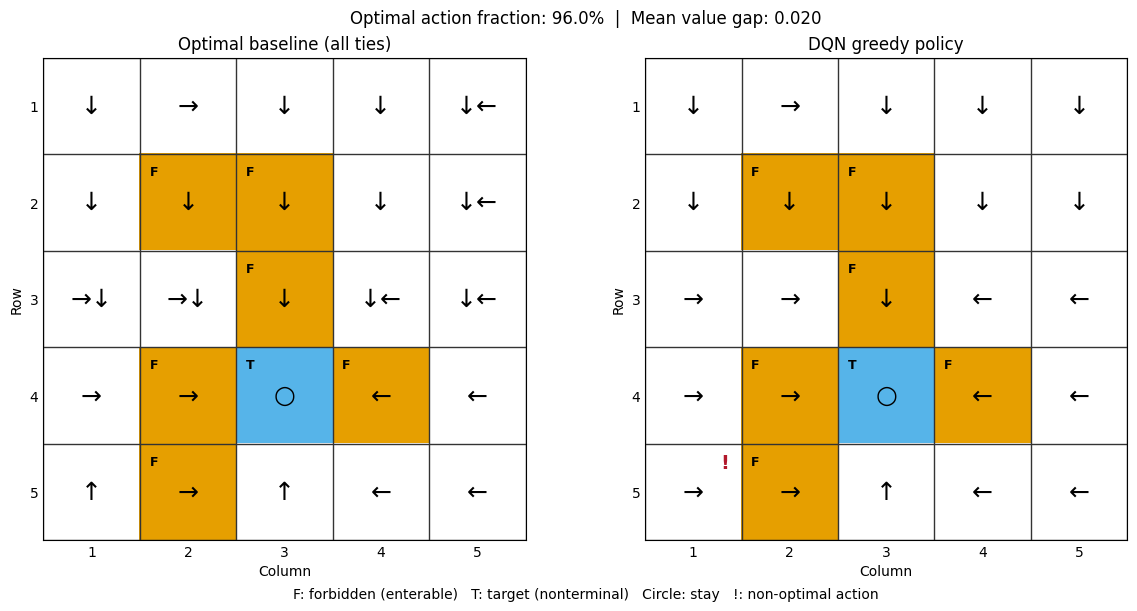

In [30]:
from matplotlib.colors import ListedColormap
from visualize import FORBIDDEN_COLOR, TARGET_COLOR

rows, cols = cfg.env.grid.shape
symbols = np.array(["↑", "→", "↓", "←", "○"])
dqn_actions = np.eye(5, dtype=bool)[dqn_policy]
fig, axes = plt.subplots(1, 2, figsize=(12, 6), layout="constrained")

for ax, action_mask, title in zip(
    axes,
    (baseline["optimal_actions"], dqn_actions),
    ("Optimal baseline (all ties)", "DQN greedy policy"),
):
    ax.imshow(cfg.env.grid, cmap=ListedColormap(["white", FORBIDDEN_COLOR, TARGET_COLOR]),
              vmin=0, vmax=2, origin="upper", interpolation="nearest")
    for row in range(rows):
        for col in range(cols):
            ax.text(col, row, "".join(symbols[action_mask[row, col]]),
                    ha="center", va="center", fontsize=18)
            label = {1: "F", 2: "T"}.get(int(cfg.env.grid[row, col]))
            if label:
                ax.text(col - 0.40, row - 0.28, label, fontsize=9, fontweight="bold")
            if ax is axes[1] and not comparison["optimal_action_mask"][row, col]:
                ax.text(col + 0.32, row - 0.25, "!", color="#B2182B",
                        fontsize=14, fontweight="bold", ha="center")
    ax.set_xticks(np.arange(cols), labels=np.arange(1, cols + 1))
    ax.set_yticks(np.arange(rows), labels=np.arange(1, rows + 1))
    ax.set_xticks(np.arange(cols + 1) - 0.5, minor=True)
    ax.set_yticks(np.arange(rows + 1) - 0.5, minor=True)
    ax.grid(which="minor", color="#333333", linewidth=1)
    ax.tick_params(which="both", length=0)
    ax.set(title=title, xlabel="Column", ylabel="Row", aspect="equal")

fig.suptitle(f"Optimal action fraction: {metrics['optimal_action_fraction']:.1%}  |  "
             f"Mean value gap: {metrics['mean_value_gap']:.3f}")
fig.supxlabel("F: forbidden (enterable)   T: target (nonterminal)   Circle: stay   !: non-optimal action",
              fontsize=10)
comparison_path = output_dir / "dqn_baseline_comparison.png"
fig.savefig(comparison_path, dpi=180, facecolor="white")
print(f"Comparison figure saved to: {comparison_path.resolve()}")
plt.show()